In [55]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plays = pd.read_csv('fbs_fbs_wildcats.csv')


C:\Users\bchm5\AppData\Local\Temp\ipykernel_30592\4230345852.py:6: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  plays = pd.read_csv('fbs_fbs_wildcats.csv')


In [58]:
# set all plays
plays.loc[:, 'first_down_gained_numeric'] = \
    plays['first_down_gained'].fillna(0)

teams = plays.groupby(['season', 'offense']).agg(
    plays=('wildcat_play', 'size'),
    first_down_rate=('first_down_gained_numeric', 'mean'),
).reset_index().sort_values(['season', 'first_down_rate'], ascending=[True, False])
teams.sort_values('plays', ascending=False)

# set wildcats
wildcats = plays[plays['wildcat_play'] == 1]

wildcat_teams = wildcats.groupby(['season', 'offense']).agg(
    plays=('wildcat_play', 'size'),
    first_down_rate=('first_down_gained_numeric', 'mean'),
).reset_index().sort_values(['season', 'first_down_rate'], ascending=[True, False])
wildcat_teams.sort_values('plays', ascending=False)

,season,offense,plays,first_down_rate
99,2025,UTUN,47,0.404255
39,2025,LATC,45,0.244444
53,2025,MSUN,38,0.552632
27,2025,ILNO,29,0.620690
62,2025,NVLV,28,0.428571
...,...,...,...,...
58,2025,NCUN,1,0.000000
71,2025,OHUN,1,0.000000
84,2025,TNVA,1,0.000000
89,2025,TXHO,1,0.000000


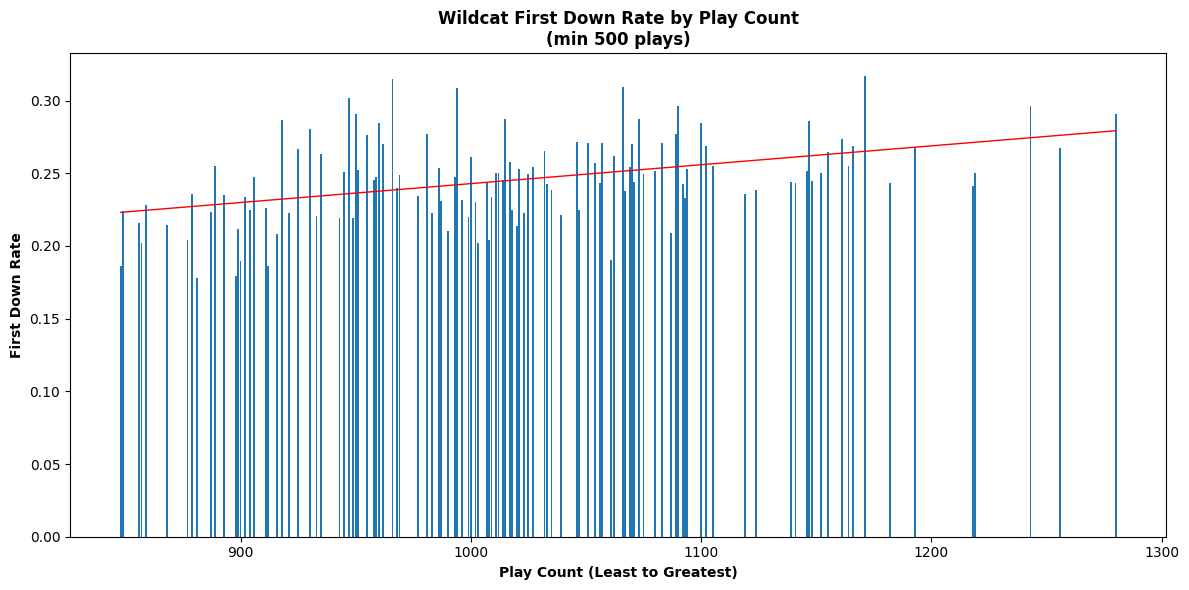

In [63]:
filtered = (
    teams[teams['plays'] > 500]
    .sort_values(by='plays', ascending=True)
)

x = filtered['plays']
y = filtered['first_down_rate']

plt.figure(figsize=(12, 6))

# Bars
plt.bar(x, y)

# ----- Regression Line -----
z = np.polyfit(x, y, 1)          # linear fit
p = np.poly1d(z)

# Smooth line across range
x_line = np.linspace(x.min(), x.max(), 100)
plt.plot(x_line, p(x_line), linewidth=1, color='red')

plt.xlabel('Play Count (Least to Greatest)', fontweight='bold')
plt.ylabel('First Down Rate', fontweight='bold')
plt.title('Wildcat First Down Rate by Play Count\n(min 500 plays)',
          fontweight='bold')

plt.tight_layout()
plt.show()

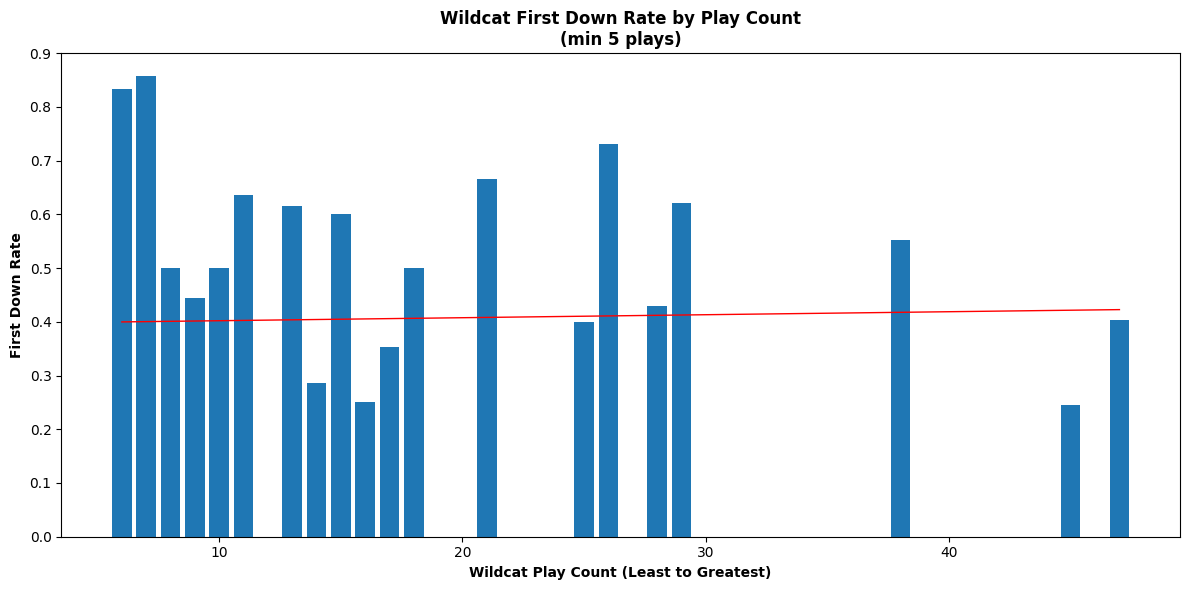

In [ ]:
# Filter and sort
filtered = (
    wildcat_teams[wildcat_teams['plays'] > 5]
    .sort_values(by='plays', ascending=True)
)

x = filtered['plays']
y = filtered['first_down_rate']

plt.figure(figsize=(12, 6))

# Bars
plt.bar(x, y)

# ----- Regression Line -----
z = np.polyfit(x, y, 1)          # linear fit
p = np.poly1d(z)

# Smooth line across range
x_line = np.linspace(x.min(), x.max(), 100)
plt.plot(x_line, p(x_line), linewidth=1, color='red')

plt.xlabel('Wildcat Play Count (Least to Greatest)', fontweight='bold')
plt.ylabel('First Down Rate', fontweight='bold')
plt.title('Wildcat First Down Rate by Play Count\n(min 5 plays)',
          fontweight='bold')

plt.tight_layout()
plt.show()

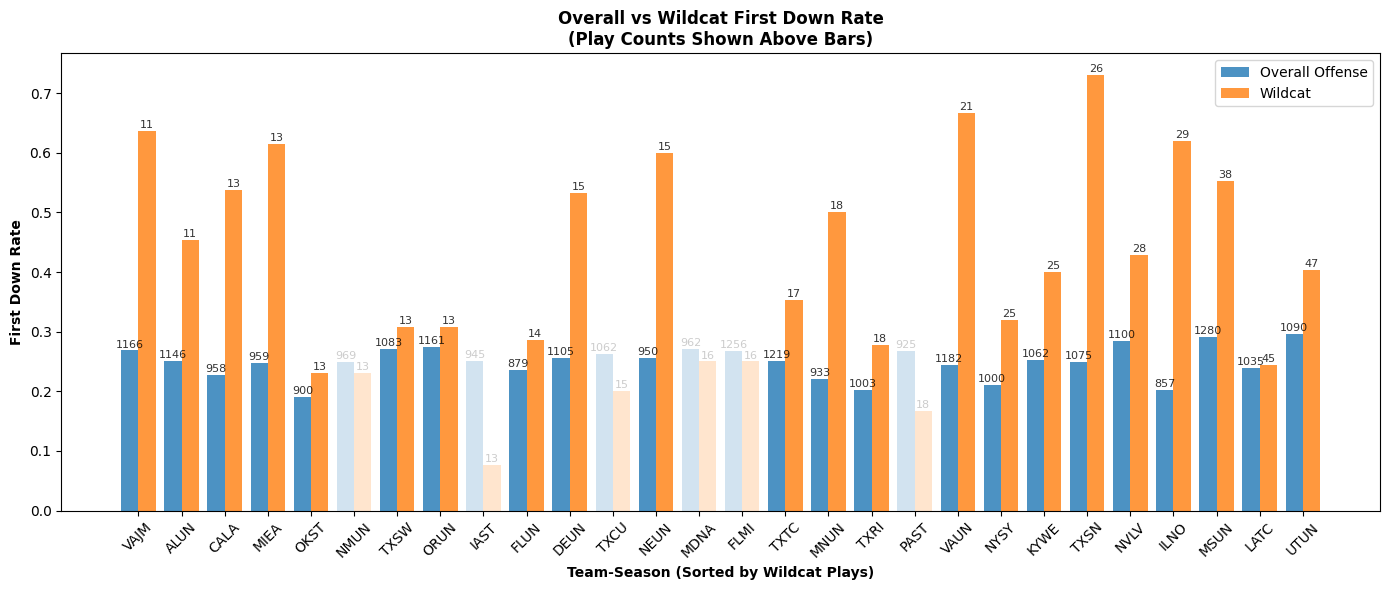

In [73]:

merged = pd.merge(
    wildcat_teams,
    teams,
    on=['season', 'offense'],
    suffixes=('_wildcat', '_overall')
)

merged = merged[
    (merged['plays_wildcat'] > 10) &
    (merged['plays_overall'] > 500)
].sort_values(by='plays_wildcat', ascending=True)

x = np.arange(len(merged))
width = 0.4

plt.figure(figsize=(14, 6))

alphas_overall = [
    0.8 if o < w else 0.2
    for o, w in zip(
        merged['first_down_rate_overall'],
        merged['first_down_rate_wildcat']
    )
]

bars1 = plt.bar(
    x - width/2,
    merged['first_down_rate_overall'],
    width,
    label='Overall Offense',
    alpha=None
)

for bar, alpha in zip(bars1, alphas_overall):
    bar.set_alpha(alpha)

bars2 = plt.bar(
    x + width/2,
    merged['first_down_rate_wildcat'],
    width,
    label='Wildcat'
)

for bar, alpha in zip(bars2, alphas_overall):
    bar.set_alpha(alpha)

# Play Count Labels 
for i in range(len(merged)):
    alpha_text = alphas_overall[i]  # Use the same alpha as the bar

    # Overall plays
    plt.text(
        x[i] - width/2,
        merged['first_down_rate_overall'].iloc[i] + 0.005,
        f"{merged['plays_overall'].iloc[i]}",
        ha='center',
        fontsize=8,
        color=(0, 0, 0, alpha_text)  # RGBA (black with transparency)
    )

    # Wildcat plays
    plt.text(
        x[i] + width/2,
        merged['first_down_rate_wildcat'].iloc[i] + 0.005,
        f"{merged['plays_wildcat'].iloc[i]}",
        ha='center',
        fontsize=8,
        color=(0, 0, 0, alpha_text)
    )

plt.xlabel('Team-Season (Sorted by Wildcat Plays)', fontweight='bold')
plt.ylabel('First Down Rate', fontweight='bold')
plt.title('Overall vs Wildcat First Down Rate\n(Play Counts Shown Above Bars)',
          fontweight='bold')

plt.xticks(x, merged['offense'], rotation=45)
plt.legend()

plt.tight_layout()
plt.show()

In [28]:
# for col in wildcats.select_dtypes(include='number').columns:
#     if abs(wildcats['first_down_gained_numeric'].corr(wildcats[col])) > 0.078:
#         print(col, "   ", round(wildcats['first_down_gained_numeric'].corr(wildcats[col]), 4))

| Feature | Correlation |
|---|---|
| **Positive** | |
| down | 0.3211 |
| box_players_on_los_count | 0.2036 |
| yards_after_contact | 0.1893 |
| box_players_count | 0.1703 |
| pass_depth | 0.1623 |
| yards_after_catch | 0.1533 |
| num_pass_blockers | 0.1482 |
| missed_tackle | 0.1281 |
| trick_play | 0.1003 |
| def_penalty | 0.0853 |
| drive_play | 0.0782 |
| **Negative** | |
| distance | -0.3751 |
| drive_end_field_position | -0.2372 |
| safety_count | -0.1561 |
| bunched_count | -0.1127 |
| unbalanced | -0.1013 |
| pressure | -0.0949 |
| option | -0.0942 |
